# Autoencoder for Image Denoising (MNIST)

## 1. Import Libraries

In [5]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [6]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Extracted successfully!")

Extracted successfully!


In [7]:

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

## 2. Load Dataset

In [8]:
base_dir='mnist_png/training'
images=[]
for digit in sorted(os.listdir(base_dir)):
    path=os.path.join(base_dir,digit)
    if os.path.isdir(path):
        for f in os.listdir(path):
            img=img_to_array(load_img(os.path.join(path,f),color_mode='grayscale',target_size=(28,28)))/255.0
            images.append(img)
X=np.array(images,dtype='float32')
print(X.shape)

(60000, 28, 28, 1)


## 3. Train/Test Split and Add Noise

In [9]:
X_train,X_val=train_test_split(X,test_size=0.1,random_state=42)
noise_factor=0.5
X_train_noisy=np.clip(X_train+noise_factor*np.random.normal(size=X_train.shape),0,1)
X_val_noisy=np.clip(X_val+noise_factor*np.random.normal(size=X_val.shape),0,1)

## 4. Build Autoencoder

In [10]:
inp=tf.keras.layers.Input((28,28,1))
x=tf.keras.layers.Conv2D(32,3,activation='relu',padding='same')(inp)
x=tf.keras.layers.MaxPooling2D(2,padding='same')(x)
x=tf.keras.layers.Conv2D(16,3,activation='relu',padding='same')(x)
x=tf.keras.layers.MaxPooling2D(2,padding='same')(x)
x=tf.keras.layers.Conv2D(16,3,activation='relu',padding='same')(x)
x=tf.keras.layers.UpSampling2D(2)(x)
x=tf.keras.layers.Conv2D(32,3,activation='relu',padding='same')(x)
x=tf.keras.layers.UpSampling2D(2)(x)
out=tf.keras.layers.Conv2D(1,3,activation='sigmoid',padding='same')(x)
model=tf.keras.Model(inp,out)
model.compile(optimizer='adam',loss='binary_crossentropy')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train Model

In [11]:
history=model.fit(X_train_noisy,X_train,validation_data=(X_val_noisy,X_val),epochs=10,batch_size=128)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 110s 244ms/step - loss: 0.1836 - val_loss: 0.1262
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 138s 235ms/step - loss: 0.1200 - val_loss: 0.1165
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 144s 240ms/step - loss: 0.1136 - val_loss: 0.1114
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 99s 235ms/step - loss: 0.1101 - val_loss: 0.1097
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 100s 237ms/step - loss: 0.1081 - val_loss: 0.1072
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 98s 231ms/step - loss: 0.1066 - val_loss: 0.1061
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 142s 232ms/step - loss: 0.1055 - val_loss: 0.1048
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 144s 238ms/step - loss: 0.1044 - val_loss: 0.1038
Epoch 9/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 99s 235ms/step - loss: 0.1035 - val_loss: 0.1031
Epoch 10/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 140s 231ms/step - loss: 0.1028 - val_loss: 0.1024


## 6. Plot Loss

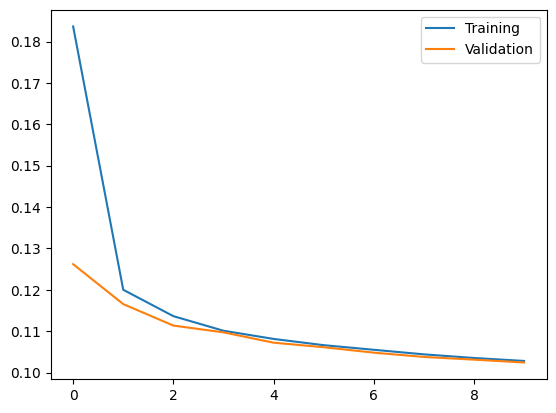

In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Training','Validation'])
plt.show()

## 7. Display Results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


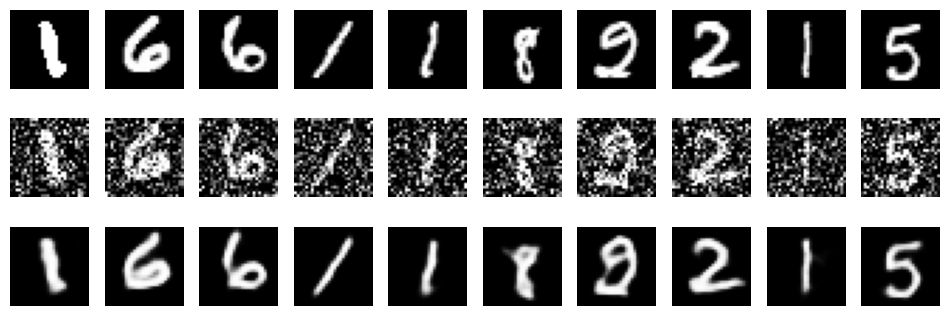

In [13]:
pred=model.predict(X_val_noisy[:10])
fig,ax=plt.subplots(3,10,figsize=(12,4))
for i in range(10):
    ax[0,i].imshow(X_val[i].squeeze(),cmap='gray'); ax[0,i].axis('off')
    ax[1,i].imshow(X_val_noisy[i].squeeze(),cmap='gray'); ax[1,i].axis('off')
    ax[2,i].imshow(pred[i].squeeze(),cmap='gray'); ax[2,i].axis('off')
plt.show()